In [22]:
import numpy as np
from numpy import random as nprnd
import random as rnd
import pandas as pd
import string as str
from math import *

#scipy stat
import scipy.stats as ss
from scipy import stats
from scipy.stats import linregress,norm, kurtosis, moment,iqr,binom, binomtest,gmean
from scipy.stats import expon,zscore,zmap
from scipy.stats import t,ttest_ind
from scipy.stats import f,f_oneway
from scipy.stats import boxcox
from scipy.stats import skewnorm,skew
from scipy.stats import pearsonr
from scipy.linalg import toeplitz
#scipy signals library
from scipy import signal
#scipy calculus library
import scipy.integrate as spi



#scipy chi
from scipy.stats import chi,chi2_contingency,chi2

import math

import os
import time

import csv

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.style as style
import seaborn as sns
# Pkg import Date Time
from datetime import datetime
from datetime import timedelta
from pandas.tseries.offsets import Hour, Minute
from pandas.tseries.offsets import Day, MonthEnd
import pytz
from pandas.tseries.frequencies import to_offset
#import arviz as az
import plotly
from sympy import symbols, Eq, solve
import re #extract cofficient

###################################################
'''Statemodels'''
###################################################
# # Ordinary Least Squares
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
import statsmodels.stats.power as smp
from statsmodels.regression.linear_model import OLS
from statsmodels.stats.outliers_influence import OLSInfluence
from statsmodels.stats.stattools import durbin_watson,omni_normtest,\
                                        jarque_bera
from patsy import dmatrices,dmatrix

from zlib import crc32
import hashlib

###################################################
'''sklearn'''
###################################################
# model_selection
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import KFold, StratifiedKFold, StratifiedShuffleSplit
from sklearn.model_selection import learning_curve

# Multiclass
from sklearn.multiclass import OneVsOneClassifier

# Base
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.base import clone

# preprocessing
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.preprocessing import PolynomialFeatures

# pipeline
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline

# datasets
from sklearn.datasets import fetch_openml
from sklearn.datasets import make_blobs
from sklearn import datasets
from sklearn.datasets import make_classification
from sklearn.datasets import load_iris
from sklearn.datasets import load_sample_image

# metrics

from sklearn.metrics import root_mean_squared_error

from sklearn.metrics import mean_squared_error,mean_absolute_error
from sklearn.metrics import confusion_matrix,precision_score,\
                            recall_score,f1_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay                         

# tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz

# linear_model
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDClassifier
from sklearn.linear_model import Ridge
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import LogisticRegression
#SVM
from sklearn.svm import SVC
from sklearn.svm import LinearSVC

from graphviz import Source

#ensemble
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.ensemble import BaggingClassifier

#decomposition
from sklearn.decomposition import PCA

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

from sklearn.cluster import MiniBatchKMeans

import tensorflow as tf
from tensorflow import keras

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tarfile
import urllib.request
#====================================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from tensorflow.keras import initializers
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.activations import sigmoid

import sys
from copy import deepcopy

import kagglehub
# =====================================
# caution: path[0] is reserved for script path (or '' in REPL)
sys.path.insert(1, r'C:\Users\TODO\Desktop\Abhi\AI\AI\Math\Hands-On\statemodelsStudy')
from olsRegressionAnalysis import dispAnalysisOfVariance, tableDispFormatt,getInvOfProductMat,\
                                  getRegressionEqn,\
                                  dispReghressionAnalysis,norm_scalling,getCorrelation,\
                                  get_variance_inflation_factors,goodnessOfFitTestOfParams



In [23]:
path = r'C:\Users\TODO\Desktop\Abhi\AI\AI\Math\Hands-On\Notes\mlx\stat_analysis\CH-7-POLYNOMIAL_REGRESSION_Model\DataSet\uswages.csv'

In [24]:
df = pd.read_csv(path)
df.shape,df.columns

((2000, 11),
 Index(['Unnamed: 0', 'wage', 'educ', 'exper', 'race', 'smsa', 'ne', 'mw', 'so',
        'we', 'pt'],
       dtype='object'))

[Cubical spline](https://github.com/xiaotoYang/CubicSpline/blob/master/Python/group9_python.ipynb)

In [25]:
## exper vs wage ##
data_x = df[['exper']]
data_y = df[['wage']]

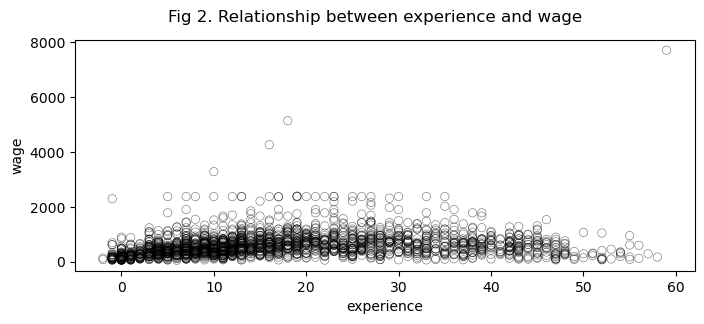

In [26]:
plt.figure(figsize=(8,3))
sns.scatterplot(data=df,x='exper',y='wage',facecolor = 'None', edgecolor = 'k', alpha = 0.5)
plt.suptitle('Fig 2. Relationship between experience and wage', fontsize=12)
plt.xlabel('experience')
plt.ylabel('wage')
plt.show()

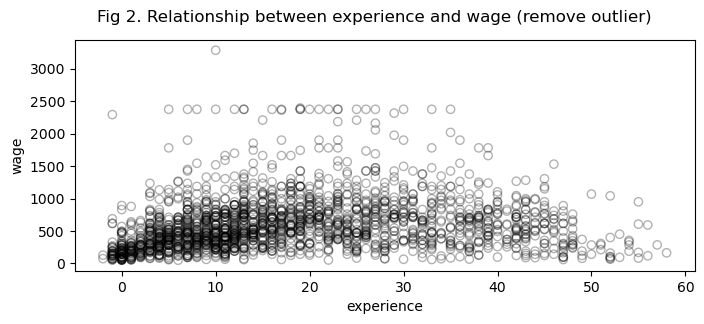

In [27]:
# remove outlier
data_ylim = df.loc[df['wage']<= 4000]
wage = data_ylim[['wage']]
exper_x = data_ylim[['exper']]

#visualize the relationship between experience and wage
plt.figure(figsize=(8,3))
plt.scatter(exper_x, wage, facecolor = 'None', edgecolor = 'k', alpha = 0.3)
plt.suptitle('Fig 2. Relationship between experience and wage (remove outlier)', fontsize=12)
plt.xlabel('experience')
plt.ylabel('wage')
plt.show()

### Test model with simple linear regression

In [28]:
exper_x = sm.add_constant(exper_x)  

# model fitting
model = sm.OLS(wage, exper_x).fit()
#print(model.summary())

# find fitted value
predictions1 = model.predict(exper_x) 
rms1 = sqrt(mean_squared_error(wage, predictions1))
print(f"rms value: {rms1}")

rms value: 404.7442876375701


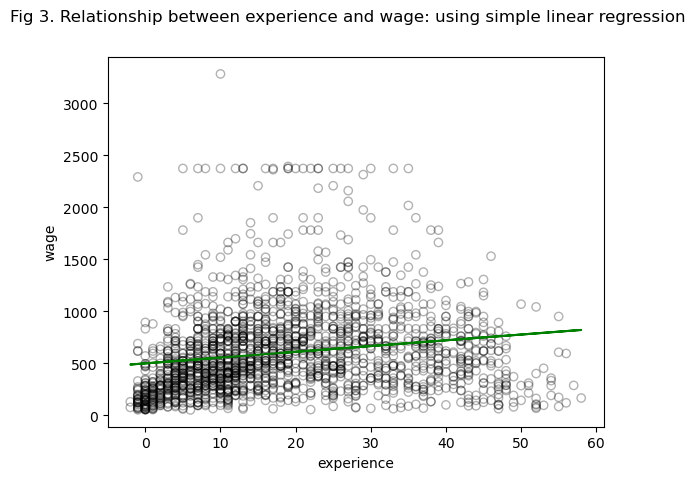

In [29]:
# data visualization
plt.scatter(exper_x['exper'], wage, facecolor = 'None', edgecolor = 'k', alpha = 0.3)
plt.plot(exper_x['exper'], predictions1, color = 'green', linewidth = 1.5)
plt.suptitle('Fig 3. Relationship between experience and wage: using simple linear regression', fontsize=12)
plt.xlabel('experience')
plt.ylabel('wage')
plt.show()


#### refit model using polynomial regression, degree = 2
#### "exper" with degree = 2

In [30]:
exper_x['exper2'] = np.power(exper_x['exper'], 2)

# model fitting
model2 = sm.OLS(wage, exper_x).fit()
#print(model2.summary())

# find fitted value
predictions2 = model2.predict(exper_x)
rms2 = sqrt(mean_squared_error(wage, predictions2))
print(f"rms value: {rms2}")



rms value: 381.38251012666694


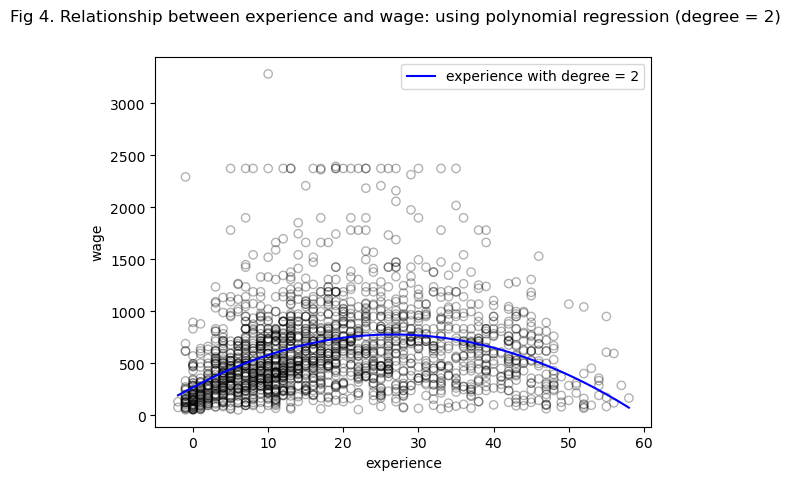

In [31]:
# reduce samples down to 100
x_lim = np.linspace(start = exper_x['exper'].min(), stop = exper_x['exper'].max(), num = 100)
x_lim_df = pd.DataFrame({'exper':x_lim})
x_lim_df['exper2'] = np.power(x_lim_df['exper'], 2)
x_lim_df = sm.add_constant(x_lim_df) 

# find fitted value using x_lim
fit_reduce = model2.predict(x_lim_df)

# data visualization
plt.scatter(exper_x['exper'], wage, facecolor = 'None', edgecolor = 'k', alpha = 0.3)
plt.plot(x_lim_df[['exper']], fit_reduce, color = 'blue', linewidth = 1.5, label='experience with degree = 2')
plt.legend()
plt.suptitle('Fig 4. Relationship between experience and wage: using polynomial regression (degree = 2)', fontsize=12)
plt.xlabel('experience')
plt.ylabel('wage')
plt.show()

In [32]:
# refit model using polynomial regression, degree = 4
# "exper" with degree = 4
exper_x['exper3'] = np.power(exper_x['exper'], 3)
exper_x['exper4'] = np.power(exper_x['exper'], 4)

# model fitting
model3 = sm.OLS(wage, exper_x).fit()
#print(model3.summary())

# find fitted value
predictions3 = model3.predict(exper_x)
# Calculating RMSE value
rms3 = sqrt(mean_squared_error(wage, predictions3))
print(rms3)

381.19635301294136


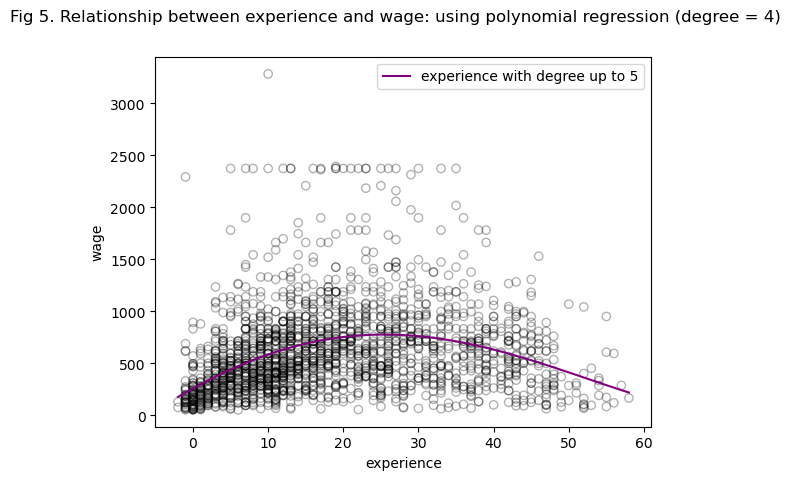

In [33]:
# reduce samples down to 100
x_lim = np.linspace(start = exper_x['exper'].min(), stop = exper_x['exper'].max(), num = 100)
x_lim_df = pd.DataFrame({'exper':x_lim})
x_lim_df['exper2'] = np.power(x_lim_df['exper'], 2)
x_lim_df['exper3'] = np.power(x_lim_df['exper'], 3)
x_lim_df['exper4'] = np.power(x_lim_df['exper'], 4)
x_lim_df = sm.add_constant(x_lim_df) 

# find fitted value using x_lim
fit_reduce2 = model3.predict(x_lim_df)

# data visualization
plt.scatter(exper_x['exper'], wage, facecolor = 'None', edgecolor = 'k', alpha = 0.3)
plt.plot(x_lim_df[['exper']], fit_reduce2, color = 'purple', linewidth = 1.5, label='experience with degree up to 5')
plt.legend()
plt.suptitle('Fig 5. Relationship between experience and wage: using polynomial regression (degree = 4)', fontsize=12)
plt.xlabel('experience')
plt.ylabel('wage')
plt.show()

In [34]:
## cubic regression ##
# cubic spline with 3 knots (quantile) at 8, 15, 27
cubic_x1 = dmatrix("bs(data, knots = (8, 15, 27), include_intercept = False)", {"data": exper_x[['exper']]}, return_type = 'dataframe')
model4 = sm.GLM(wage, cubic_x1).fit()
#print(model4.summary())

# find fitted value
predictions4 = model4.predict(cubic_x1)

# Calculating RMSE value
rms4 = sqrt(mean_squared_error(wage, predictions4))
print(rms4)

381.09127158155667


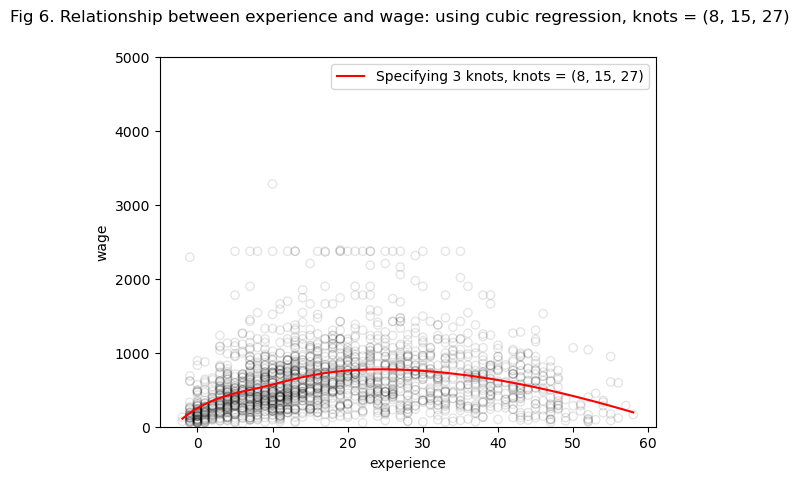

In [35]:
# reduce samples down to 100
x_lim = np.linspace(start = exper_x[['exper']].min(), stop = exper_x[['exper']].max(), num = 100)


# find fitted value using x_lim
fit_reduce3 = model4.predict(dmatrix(formula_like = "bs(train, knots = (8, 15, 27), include_intercept = False)", data = {"train": x_lim}, return_type = 'dataframe'))

# plot spline
plt.scatter(exper_x[['exper']], wage, facecolor='None', edgecolor='k', alpha=0.1)
plt.plot(x_lim, fit_reduce3, color='r', linewidth = 1.5, label='Specifying 3 knots, knots = (8, 15, 27)')
plt.legend()
plt.suptitle('Fig 6. Relationship between experience and wage: using cubic regression, knots = (8, 15, 27)', fontsize=12)
plt.ylim(0, 5000)
plt.xlabel('experience')
plt.ylabel('wage')
plt.show()
plt.show()

In [36]:
## cubic regression ##
# cubic spline with 3 knots (quantile) at 15, 30, 45
cubic_x2 = dmatrix("bs(data, knots = (15, 30, 45), include_intercept = False)", {"data": exper_x[['exper']]}, return_type = 'dataframe')
model5 = sm.GLM(wage, cubic_x2).fit()
#print(model5.summary())

# find fitted value
predictions5 = model5.predict(cubic_x2)

# Calculating RMSE value
rms5 = sqrt(mean_squared_error(wage, predictions5))
print(rms5)

381.15631270805085


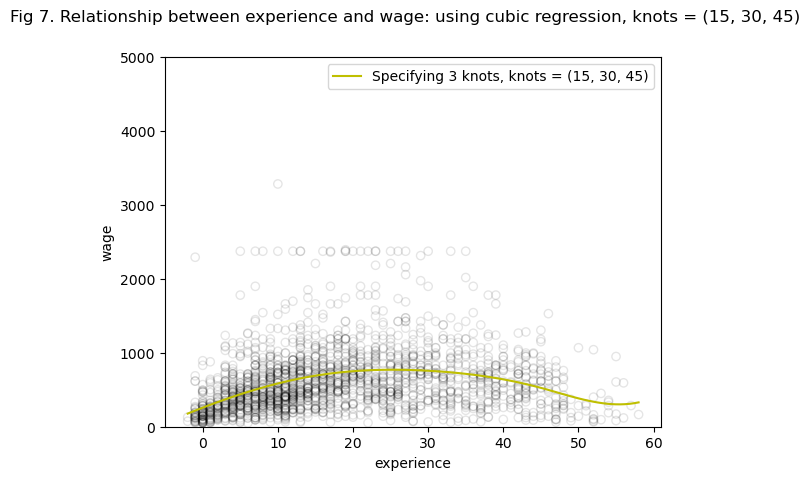

In [37]:
# reduce samples down to 100
x_lim = np.linspace(start = exper_x[['exper']].min(), stop = exper_x[['exper']].max(), num = 100)


# find fitted value using x_lim
fit_reduce4 = model5.predict(dmatrix(formula_like = "bs(train, knots = (15, 30, 45), include_intercept = False)", data = {"train": x_lim}, return_type = 'dataframe'))

# plot spline
plt.scatter(exper_x[['exper']], wage, facecolor='None', edgecolor='k', alpha=0.1)
plt.plot(x_lim, fit_reduce4, color='y', linewidth = 1.5, label='Specifying 3 knots, knots = (15, 30, 45)')
plt.legend()
plt.suptitle('Fig 7. Relationship between experience and wage: using cubic regression, knots = (15, 30, 45)', fontsize=12)
plt.ylim(0, 5000)
plt.xlabel('experience')
plt.ylabel('wage')
plt.show()

In [38]:
# compare root of mse
model = ['SLR', 'Polynomial (degree = 2)', 'Polynomial (degree = 4)', 'Spline(knots = 8, 15, 27)', 'Spline(knots = 15, 30, 45)']
RMSE = [rms1, rms2, rms3, rms4, rms5]
compare = pd.DataFrame({'Model':model, 'RMSE':RMSE})
print(compare)

                        Model        RMSE
0                         SLR  404.744288
1     Polynomial (degree = 2)  381.382510
2     Polynomial (degree = 4)  381.196353
3   Spline(knots = 8, 15, 27)  381.091272
4  Spline(knots = 15, 30, 45)  381.156313


#### Cubical spline with continuty restrictions

- knots = (15, 30, 45)
- knots =  (8, 15, 27)

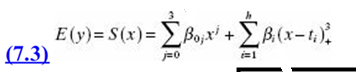

In [39]:
# remove outlier
data_ylim = df.loc[df['wage']<= 4000]
#spline_formula = 
data_ylim.columns = ['Unnamed: 0', 'Yw', 'educ', 'Xp', 'race', 'smsa', 'ne', 'mw', 'so',
       'we', 'pt']
wage = data_ylim[['Yw']]
exper_x = data_ylim[['Xp']]
#print(model2.summary())



In [40]:
data_ylim = df.loc[df['wage']<= 4000]
#spline_formula = 
data_ylim.columns = ['Unnamed: 0', 'Yw', 'educ', 'Xp', 'race', 'smsa', 'ne', 'mw', 'so',
       'we', 'pt']
dfX = data_ylim.loc[:,['Yw', 'Xp']]
dfX['Xp15'] = dfX['Xp'] - 15
dfX['Xp30'] = dfX['Xp'] - 30
dfX['Xp45'] = dfX['Xp'] - 45
exper_x = dfX.drop('Yw',axis=1)
spline_formula = 'Yw ~ Xp + Xp**2 + Xp**3 + Xp15**3 + Xp30**3 + Xp45**3'
#spline_formula = 'Yw ~ Xp'
spline_continuos = smf.ols(formula = spline_formula,data=dfX).fit()
# find fitted value
#print(f"{spline_continuos.fittedvalues}")
rms = sqrt(mean_squared_error(wage, spline_continuos.fittedvalues))
rms

404.7442876375701

In [41]:
splin_prictc= spline_continuos.predict(exper_x)
#rms_spline = sqrt(mean_squared_error(wage, splin_prictc))
print(f"rms value: {spline_continuos.mse_model}")
rms5 = sqrt(mean_squared_error(wage, splin_prictc))
print(rms5)

rms value: 10949960.99585855
404.7442876375701


#### Hypothesis testing

#### Non parametric regressions

Kernel smoothing


Text(0.5, 1.0, 'No transformanations')

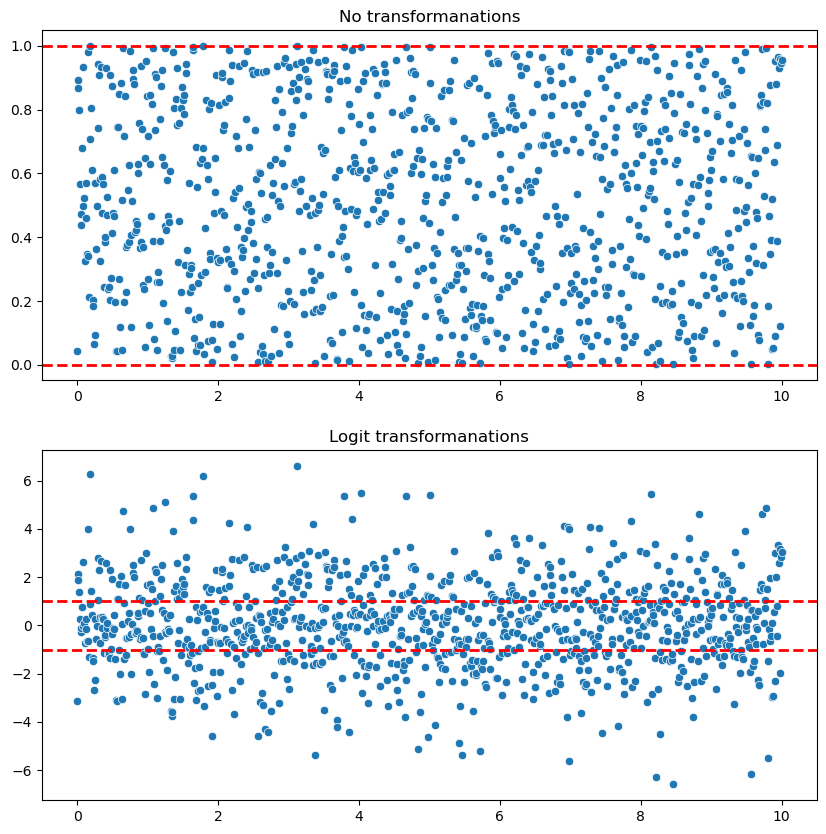

In [42]:
# Generate 1000 samples between 0 and 1 (excluding exact 0 and 1 to avoid division by zero)
x = np.linspace(0,10,1000)
samples = np.random.uniform(low=0.001, high=0.999, size=1000)

# Apply logit transformation
logit_transformed = np.log(samples / (1 - samples))
fig, axs = plt.subplots(2, 1, figsize=(10, 10))

# Optional: inspect the first few transformed values
sns.scatterplot(x=x,y=logit_transformed,ax=axs[1])
axs[1].axhline(y=0.999, color='red', linestyle='--', linewidth=2)
axs[1].axhline(y=-0.999, color='red', linestyle='--', linewidth=2)
axs[1].set_title("Logit transformanations")

sns.scatterplot(x=x,y=samples,ax=axs[0])
axs[0].axhline(y=0.0, color='red', linestyle='--', linewidth=2)
axs[0].axhline(y=0.999, color='red', linestyle='--', linewidth=2)
axs[0].set_title("No transformanations")

In above figure you can see after logit trIn above figure you can see after logit transformations o/p range changed. Before Logit transformations, Output range between 0 to 1. After transformations, range become -**7 to 7**. This is actually logit do, expand range on real number line ***-∞ to +∞*** tasformanations o/p range chenged. Before Logit